In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, feature
import time

Image shape: (408, 612)


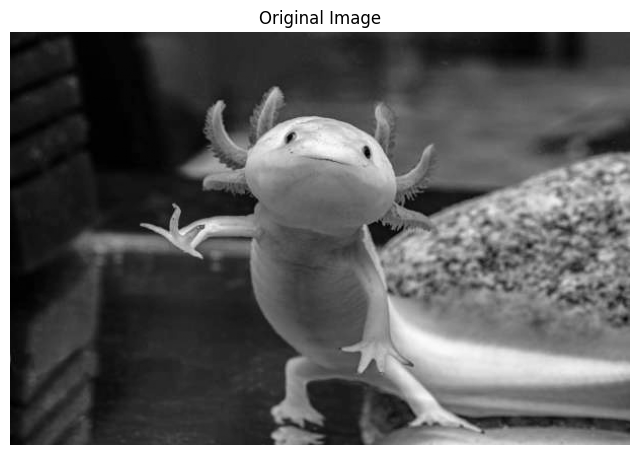

In [2]:
# Load input image
img = cv2.imread('../../input.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f"Image shape: {img_gray.shape}")
plt.figure(figsize=(8, 6))
plt.imshow(img_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [3]:
def sobel_edge_detection(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.sqrt(sobelx**2 + sobely**2)
    return np.uint8(sobel_combined)

def prewitt_edge_detection(image):
    kernelx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=int)
    kernely = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
    prewittx = cv2.filter2D(image, cv2.CV_16S, kernelx)
    prewitty = cv2.filter2D(image, cv2.CV_16S, kernely)
    prewitt_combined = np.sqrt(prewittx**2 + prewitty**2)
    return np.uint8(prewitt_combined)

def roberts_edge_detection(image):
    kernelx = np.array([[1, 0], [0, -1]], dtype=int)
    kernely = np.array([[0, 1], [-1, 0]], dtype=int)
    robertsx = cv2.filter2D(image, cv2.CV_16S, kernelx)
    robertsy = cv2.filter2D(image, cv2.CV_16S, kernely)
    roberts_combined = np.sqrt(robertsx**2 + robertsy**2)
    return np.uint8(roberts_combined)

def laplacian_gaussian_edge_detection(image):
    return cv2.Laplacian(cv2.GaussianBlur(image, (3, 3), 0), cv2.CV_64F)

def canny_edge_detection(image):
    return cv2.Canny(image, 50, 150)

In [ ]:
# Apply edge detection methods and measure performance
methods = {
    'Sobel': sobel_edge_detection,
    'Prewitt': prewitt_edge_detection,
    'Roberts': roberts_edge_detection,
    'Laplacian of Gaussian': laplacian_gaussian_edge_detection,
    'Canny': canny_edge_detection
}

results = {}
execution_times = {}

for name, method in methods.items():
    start_time = time.time()
    edge_result = method(img_gray)
    end_time = time.time()

    results[name] = edge_result
    execution_times[name] = end_time - start_time
    print(f"{name}: {execution_times[name]:.6f} seconds")

Sobel: 0.005153 seconds
Prewitt: 0.012270 seconds
Roberts: 0.001412 seconds
Laplacian of Gaussian: 0.003492 seconds
Canny: 0.003820 seconds


C:\Users\Pruthvi\AppData\Local\Temp\ipykernel_9136\2213191997.py:12: RuntimeWarning: invalid value encountered in sqrt
  prewitt_combined = np.sqrt(prewittx**2 + prewitty**2)
C:\Users\Pruthvi\AppData\Local\Temp\ipykernel_9136\2213191997.py:13: RuntimeWarning: invalid value encountered in cast
  return np.uint8(prewitt_combined)


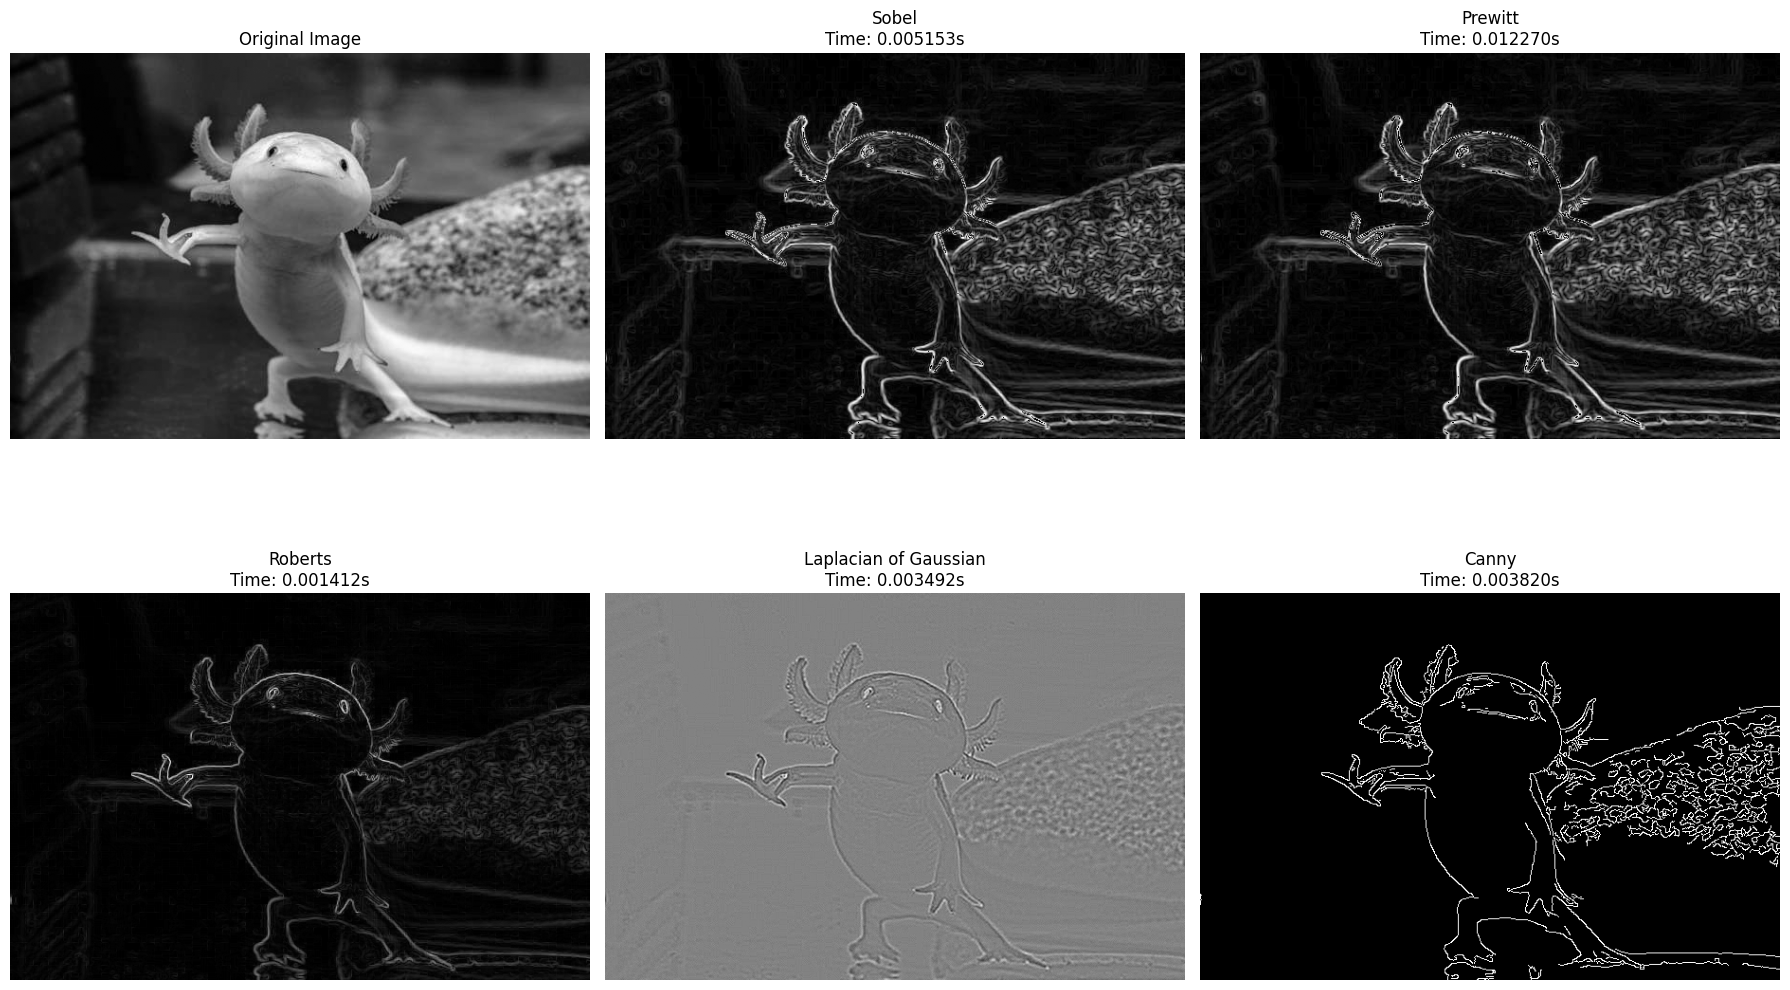

In [5]:
# Display results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

for i, (name, result) in enumerate(results.items(), 1):
    axes[i].imshow(result, cmap='gray')
    axes[i].set_title(f'{name}\nTime: {execution_times[name]:.6f}s')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Performance comparison
print("\nPerformance Comparison:")
print("-" * 40)
sorted_times = sorted(execution_times.items(), key=lambda x: x[1])

print("Execution Time Ranking (fastest to slowest):")
for i, (method, time_taken) in enumerate(sorted_times, 1):
    print(f"{i}. {method}: {time_taken:.6f} seconds")

# Calculate relative performance
fastest_time = sorted_times[0][1]
print(f"\nRelative Performance (compared to fastest - {sorted_times[0][0]}):")
for method, time_taken in sorted_times:
    speedup = time_taken / fastest_time
    print(f"{method}: {speedup:.2f}x")


Performance Comparison:
----------------------------------------
Execution Time Ranking (fastest to slowest):
1. Roberts: 0.001412 seconds
2. Laplacian of Gaussian: 0.003492 seconds
3. Canny: 0.003820 seconds
4. Sobel: 0.005153 seconds
5. Prewitt: 0.012270 seconds

Relative Performance (compared to fastest - Roberts):
Roberts: 1.00x
Laplacian of Gaussian: 2.47x
Canny: 2.71x
Sobel: 3.65x
Prewitt: 8.69x
